<a href="https://colab.research.google.com/github/Shubham-mohapatra/AgroBuddy/blob/main/AgroBuddy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle


In [2]:
!kaggle datasets download -d vipoooool/new-plant-diseases-dataset


Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset
License(s): copyright-authors
new-plant-diseases-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)


In [3]:
import zipfile
with zipfile.ZipFile("new-plant-diseases-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("new-plant-diseases-dataset")



In [4]:
import os

base_dir = "new-plant-diseases-dataset"
dataset_dir = os.path.join(base_dir, '/content/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)')

train_dir = os.path.join(dataset_dir, 'train')
valid_dir = os.path.join(dataset_dir, 'valid')





In [5]:
train_dir = os.path.join(dataset_dir, 'train')
valid_dir = os.path.join(dataset_dir, 'valid')

# Confirm paths exist
print("Train directory exists:", os.path.exists(train_dir))
print("Validation directory exists:", os.path.exists(valid_dir))


Train directory exists: True
Validation directory exists: True


In [6]:
import os

print("Current working directory:", os.getcwd())

# List all files and folders in the current directory
print("Contents of current directory:", os.listdir())


Current working directory: /content
Contents of current directory: ['.config', 'new-plant-diseases-dataset.zip', 'new-plant-diseases-dataset', 'model_checkpoint.keras', 'training_history.pkl', 'sample_data']


In [7]:
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt


In [8]:
dataset_dir = os.path.join(base_dir, 'New Plant Diseases Dataset(Augmented)')

In [9]:
print("Contents of dataset_dir:", os.listdir(dataset_dir))


Contents of dataset_dir: ['New Plant Diseases Dataset(Augmented)']


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data generators for training and validation
datagen = ImageDataGenerator(rescale=1.0/255.0,validation_split=0.2)  # Normalize pixel values to [0, 1]

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),  # Resize images to 224x224
    batch_size=32,
    class_mode='categorical',  # Multi-class classification
    shuffle = True,
    subset='training'

)

valid_data = datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle = False,
    subset = 'validation'

)

test_datagen = ImageDataGenerator(rescale=1.0/255.0)

test_data = test_datagen.flow_from_directory(
    valid_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle = False
)
print("Class indices:", test_data.class_indices)


Found 56251 images belonging to 38 classes.
Found 3503 images belonging to 38 classes.
Found 17572 images belonging to 38 classes.
Class indices: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawber

In [11]:
def count_images_in_class(data_dir):
    class_counts = {}
    for class_name in os.listdir(data_dir):
        class_path = os.path.join(data_dir, class_name)
        if os.path.isdir(class_path):
            class_counts[class_name] = len(os.listdir(class_path))
    return class_counts

train_counts = count_images_in_class(train_dir)
valid_counts = count_images_in_class(valid_dir)

print("Images in training set:", train_counts)
print("Images in validation set:", valid_counts)


Images in training set: {'Tomato___Tomato_mosaic_virus': 1790, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 1642, 'Tomato___Bacterial_spot': 1702, 'Blueberry___healthy': 1816, 'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 1961, 'Pepper,_bell___healthy': 1988, 'Apple___healthy': 2008, 'Tomato___Spider_mites Two-spotted_spider_mite': 1741, 'Tomato___Septoria_leaf_spot': 1745, 'Pepper,_bell___Bacterial_spot': 1913, 'Raspberry___healthy': 1781, 'Tomato___Early_blight': 1920, 'Corn_(maize)___Common_rust_': 1907, 'Orange___Haunglongbing_(Citrus_greening)': 2010, 'Apple___Cedar_apple_rust': 1760, 'Cherry_(including_sour)___Powdery_mildew': 1683, 'Cherry_(including_sour)___healthy': 1826, 'Peach___Bacterial_spot': 1838, 'Grape___healthy': 1692, 'Strawberry___healthy': 1824, 'Potato___healthy': 1824, 'Apple___Apple_scab': 2016, 'Grape___Esca_(Black_Measles)': 1920, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1722, 'Squash___Powdery_mildew': 1736, 'Corn_(maize)___healthy': 1859, 'Apple___

In [12]:

print("Classes:", train_data.class_indices)
print("Number of images in training set:", train_data.samples)
print("Number of batches per epoch:", train_data.batch_size)

# sample batch and check shape
x_batch, y_batch = next(train_data)  # Fetch one batch
print("Shape of one image in batch:", x_batch.shape)


Classes: {'Apple___Apple_scab': 0, 'Apple___Black_rot': 1, 'Apple___Cedar_apple_rust': 2, 'Apple___healthy': 3, 'Blueberry___healthy': 4, 'Cherry_(including_sour)___Powdery_mildew': 5, 'Cherry_(including_sour)___healthy': 6, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 7, 'Corn_(maize)___Common_rust_': 8, 'Corn_(maize)___Northern_Leaf_Blight': 9, 'Corn_(maize)___healthy': 10, 'Grape___Black_rot': 11, 'Grape___Esca_(Black_Measles)': 12, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 13, 'Grape___healthy': 14, 'Orange___Haunglongbing_(Citrus_greening)': 15, 'Peach___Bacterial_spot': 16, 'Peach___healthy': 17, 'Pepper,_bell___Bacterial_spot': 18, 'Pepper,_bell___healthy': 19, 'Potato___Early_blight': 20, 'Potato___Late_blight': 21, 'Potato___healthy': 22, 'Raspberry___healthy': 23, 'Soybean___healthy': 24, 'Squash___Powdery_mildew': 25, 'Strawberry___Leaf_scorch': 26, 'Strawberry___healthy': 27, 'Tomato___Bacterial_spot': 28, 'Tomato___Early_blight': 29, 'Tomato___Late_blight': 30

Shape of one image in batch: (32, 224, 224, 3)
Shape of one label batch (y): (32, 38)


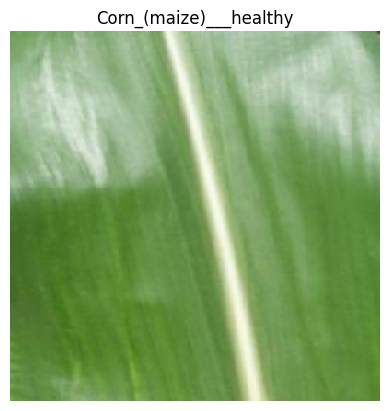

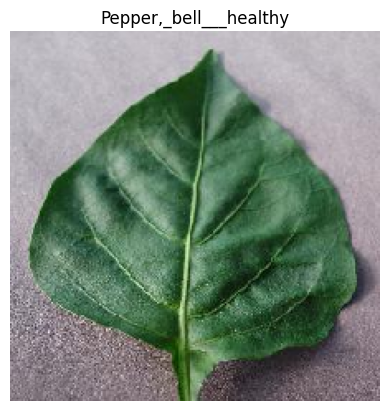

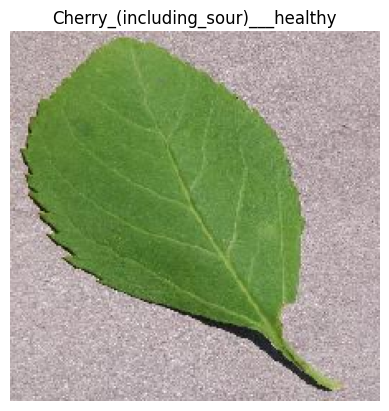

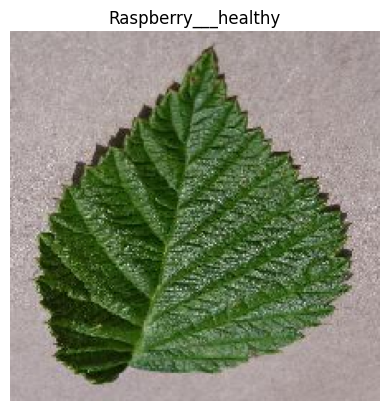

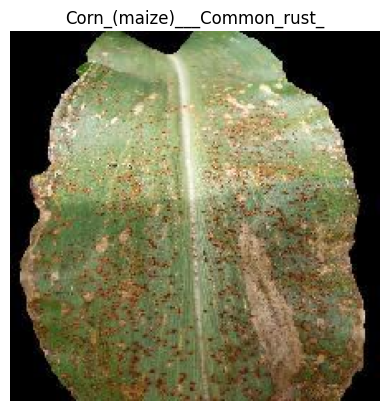

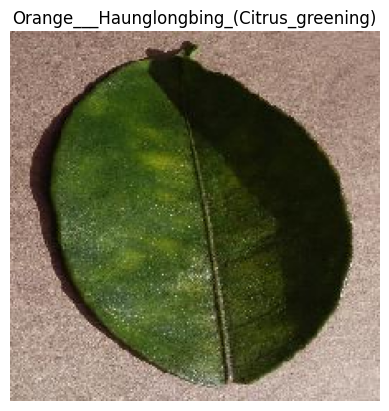

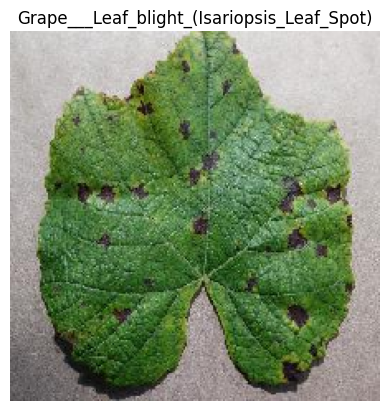

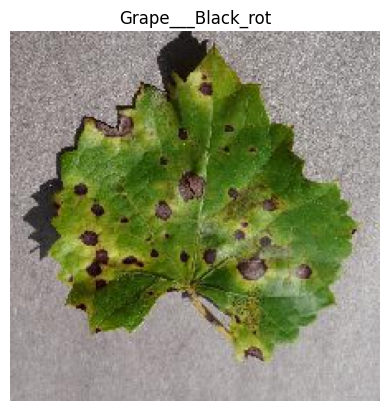

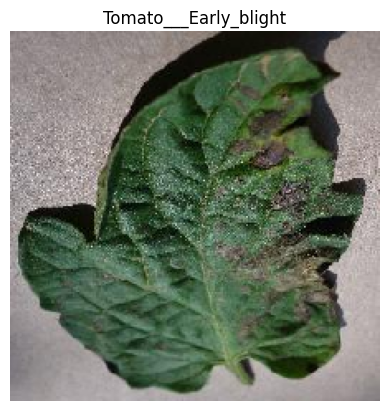

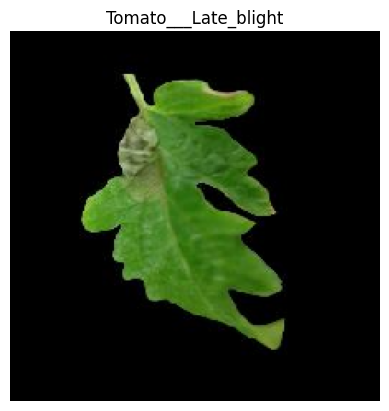

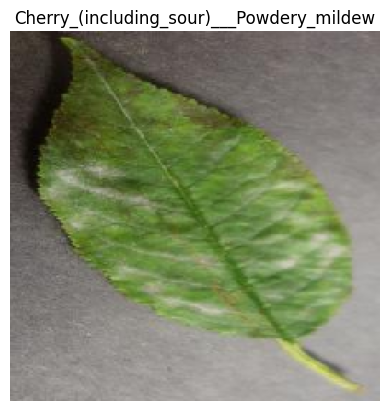

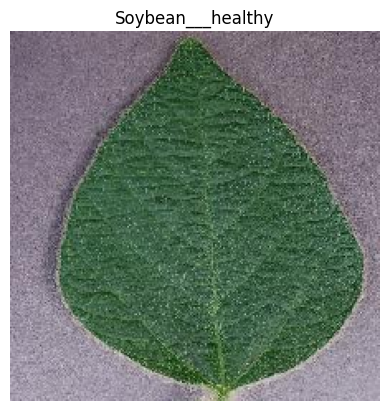

In [13]:
import matplotlib.pyplot as plt

class_names = list(train_data.class_indices.keys())

# sample batch
x_batch, y_batch = next(train_data)  # Fetch one batch
print("Shape of one image in batch:", x_batch.shape)
print("Shape of one label batch (y):", y_batch.shape)

# Rescale the first image in the batch to [0, 255]
for i in range(min(12,x_batch.shape[0])):
    image = x_batch[i]
    if image.max() <= 1.0:
      image = (image * 255).astype('uint8')  # Rescale to 0-255 and convert to uint8

      plt.imshow(image)
      plt.title(class_names[np.argmax(y_batch[i])])
      plt.axis('off')
      plt.show()


In [14]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import regularizers

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomBrightness(0.2)
])

model = tf.keras.Sequential([
     tf.keras.layers.InputLayer(input_shape=(224, 224, 3)),
    data_augmentation,
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.01)),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(38, activation='softmax')
])

model.compile(optimizer=tf.keras.optimizers.Adam(), loss='categorical_crossentropy', metrics=['accuracy'])


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


model = Sequential()

# Convolutional layer 1
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 2
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Convolutional layer 3
model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.6))  # Dropout to reduce overfitting


# Flatten layer to reshape the data for the dense layer
model.add(Flatten())

# Dense fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))  # Dropout to prevent overfitting


model.add(Dense(38, activation='softmax'))

model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 24, 24, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 9216)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │       1,179,776 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 38)                  │           4,902 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,351,718 (5.16 MB)

 Trainable params: 1,351,718 (5.16 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath='model_checkpoint.keras',  # Save the full model
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=False,            # Save the entire model, not just weights
    verbose=1
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    verbose=1,
    restore_best_weights=True
)
history = model.fit(
    train_data,
    epochs=100,
    batch_size=32,
    steps_per_epoch=54,
    validation_data=valid_data,
    callbacks=[checkpoint_callback]
)

Epoch 1/100


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.0214 - loss: 3.6399

KeyboardInterrupt: 

In [ ]:
from tensorflow.keras.models import load_model

model = load_model('model_checkpoint.h5')


In [ ]:
import pickle

# Save history
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

# Load history
with open('training_history.pkl', 'rb') as f:
    history = pickle.load(f)


In [ ]:
scores = model.evaluate(test_data)

In [ ]:
scores


In [ ]:
history


In [ ]:
history.params

In [ ]:
# Load history from the saved file if available
import pickle
try:
    with open('training_history.pkl', 'rb') as f:
        history = pickle.load(f)
except FileNotFoundError:
    print("training_history.pkl not found. Make sure you have saved the training history.")
    history = None  # or handle the case appropriately

# Access the training metrics if history is loaded
if history:
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
else:
    print("Cannot access training metrics. History not loaded.")

In [ ]:
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')

In [ ]:
# Get a batch of data from the test dataset
x_batch, y_batch = next(iter(test_data))  # Use 'iter' for compatibility

# Predict the output for the batch
predictions = model.predict(x_batch)

# Loop through a few images in the batch
for i in range(5):  # Change the range as needed to show more/less images
    # Rescale the image back to [0, 255] for visualization
    image = (x_batch[i] * 255).astype('uint8')

    # Get the actual and predicted labels
    actual_label = np.argmax(y_batch[i])
    predicted_label = np.argmax(predictions[i])

    # Print and visualize the image with labels
    print(f"Image {i} - Actual: {class_names[actual_label]}, Predicted: {class_names[predicted_label]}")
    plt.imshow(image)
    plt.axis('off')
    plt.title(f"Actual: {class_names[actual_label]}, Predicted: {class_names[predicted_label]}")
    plt.show()
